In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))



True
Tesla T4


In [ ]:
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.get_device_name(0))  # Should print something like Tesla T4

True
Tesla T4


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Standard normalization for CIFAR (mean and std of CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# In-distribution: CIFAR-10 (train + test)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)

testset_in = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
testloader_in = torch.utils.data.DataLoader(testset_in, batch_size=128,
                                             shuffle=False, num_workers=2)

# Out-of-distribution: CIFAR-100 (test only)
testset_out = torchvision.datasets.CIFAR100(root='./data', train=False,
                                             download=True, transform=transform)
testloader_out = torch.utils.data.DataLoader(testset_out, batch_size=128,
                                              shuffle=False, num_workers=2)

print("Datasets loaded!")
print(f"In-distribution (CIFAR-10 test): {len(testset_in)} samples")
print(f"Out-of-distribution (CIFAR-100 test): {len(testset_out)} samples")


100%|██████████| 170M/170M [00:05<00:00, 33.8MB/s]
100%|██████████| 169M/169M [00:04<00:00, 34.0MB/s]


Datasets loaded!
In-distribution (CIFAR-10 test): 10000 samples
Out-of-distribution (CIFAR-100 test): 10000 samples


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load ResNet-18, modify final layer for 10 classes
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(512, 10)  # CIFAR-10 has 10 classes
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# Training loop
def train(epochs=50):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/50] | Loss: {running_loss/len(trainloader):.3f} | "
                  f"Acc: {100.*correct/total:.2f}%")

train(epochs=50)

# Save the model
torch.save(model.state_dict(), 'resnet18_cifar10.pth')
print("Model saved!")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [10/50] | Loss: 0.540 | Acc: 81.25%
Epoch [20/50] | Loss: 0.288 | Acc: 90.03%
Epoch [30/50] | Loss: 0.112 | Acc: 96.11%
Epoch [40/50] | Loss: 0.001 | Acc: 100.00%
Epoch [50/50] | Loss: 0.001 | Acc: 100.00%
Model saved!


In [ ]:
import numpy as np
from sklearn.covariance import EmpiricalCovariance

# ── Helper: extract logits and features from the model ──
def get_logits_and_features(loader):
    model.eval()
    all_logits = []
    all_features = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            # Hook to get penultimate layer features
            features = []
            def hook(module, input, output):
                features.append(input[0].cpu().numpy())
            handle = model.fc.register_forward_hook(hook)
            logits = model(inputs)
            handle.remove()
            all_logits.append(logits.cpu().numpy())
            all_features.append(features[0])
    return np.concatenate(all_logits), np.concatenate(all_features)

# Get logits + features for in-dist train, in-dist test, OOD test
train_logits, train_features = get_logits_and_features(trainloader)
in_logits,    in_features    = get_logits_and_features(testloader_in)
out_logits,   out_features   = get_logits_and_features(testloader_out)

print("Logits and features extracted!")
print(f"Train features shape: {train_features.shape}")  # (50000, 512)
print(f"In-dist test features shape: {in_features.shape}")   # (10000, 512)
print(f"OOD test features shape: {out_features.shape}")      # (10000, 512)

Logits and features extracted!
Train features shape: (50000, 512)
In-dist test features shape: (10000, 512)
OOD test features shape: (10000, 512)


In [ ]:
from scipy.special import softmax
from scipy.special import logsumexp

# ── METHOD 1: Maximum Softmax Probability (MSP baseline) ──
# Higher softmax confidence = more likely in-distribution
def msp_score(logits):
    probs = softmax(logits, axis=1)
    return probs.max(axis=1)  # max class probability

msp_in  = msp_score(in_logits)
msp_out = msp_score(out_logits)
print("MSP scores computed!")

# ── METHOD 2: Energy Score ──
# Energy = log-sum-exp of logits (from "Energy-based OOD Detection", Liu et al. NeurIPS 2020)
# Lower energy = more in-distribution (we negate so higher = more in-distribution)
def energy_score(logits, T=1.0):
    return T * logsumexp(logits / T, axis=1)

energy_in  = energy_score(in_logits)
energy_out = energy_score(out_logits)
print("Energy scores computed!")

# ── METHOD 3: Mahalanobis Distance ──
# Fits a class-conditional Gaussian to training features
# Distance to nearest class mean = OOD score (lower distance = more in-distribution)
def mahalanobis_score(train_features, train_logits, test_features):
    train_labels = train_logits.argmax(axis=1)
    num_classes = 10
    class_means = []

    # Compute per-class mean
    for c in range(num_classes):
        class_mask = train_labels == c
        class_means.append(train_features[class_mask].mean(axis=0))
    class_means = np.array(class_means)  # (10, 512)

    # Fit shared covariance matrix
    centered = train_features - class_means[train_labels]
    cov = EmpiricalCovariance().fit(centered)
    precision = cov.precision_  # inverse covariance matrix

    # Compute Mahalanobis distance to nearest class
    scores = []
    for feat in test_features:
        dists = []
        for mean in class_means:
            diff = feat - mean
            dist = diff @ precision @ diff
            dists.append(dist)
        scores.append(-min(dists))  # negate: higher score = more in-distribution
    return np.array(scores)

print("Computing Mahalanobis scores (this takes ~2-3 minutes)...")
maha_in  = mahalanobis_score(train_features, train_logits, in_features)
maha_out = mahalanobis_score(train_features, train_logits, out_features)
print("Mahalanobis scores computed!")


MSP scores computed!
Energy scores computed!
Computing Mahalanobis scores (this takes ~2-3 minutes)...
Mahalanobis scores computed!



Method                  AUROC
------------------------------
MSP (Baseline)       0.7523
Energy Score         0.7728
Mahalanobis          0.6930


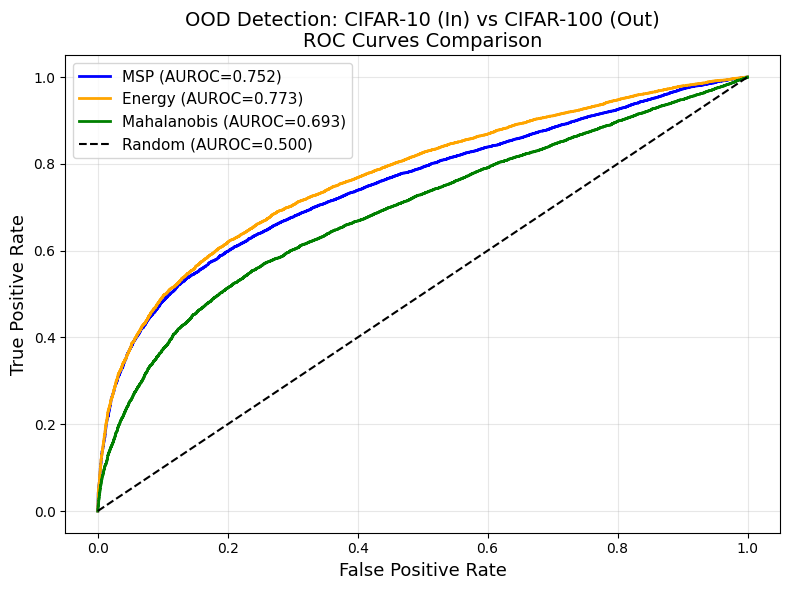

Plot saved as ood_roc_curves.png


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def compute_auroc(in_scores, out_scores):
    # Label 1 = in-distribution, 0 = OOD
    labels = np.concatenate([np.ones(len(in_scores)),
                              np.zeros(len(out_scores))])
    scores = np.concatenate([in_scores, out_scores])
    return roc_auc_score(labels, scores)

auroc_msp   = compute_auroc(msp_in, msp_out)
auroc_energy = compute_auroc(energy_in, energy_out)
auroc_maha  = compute_auroc(maha_in, maha_out)

print(f"\n{'Method':<20} {'AUROC':>8}")
print("-" * 30)
print(f"{'MSP (Baseline)':<20} {auroc_msp:.4f}")
print(f"{'Energy Score':<20} {auroc_energy:.4f}")
print(f"{'Mahalanobis':<20} {auroc_maha:.4f}")

# ── Plot ROC curves ──
fig, ax = plt.subplots(figsize=(8, 6))

for scores_in, scores_out, label, color in [
    (msp_in,    msp_out,    f"MSP (AUROC={auroc_msp:.3f})",    "blue"),
    (energy_in, energy_out, f"Energy (AUROC={auroc_energy:.3f})", "orange"),
    (maha_in,   maha_out,   f"Mahalanobis (AUROC={auroc_maha:.3f})", "green"),
]:
    labels = np.concatenate([np.ones(len(scores_in)), np.zeros(len(scores_out))])
    scores = np.concatenate([scores_in, scores_out])
    fpr, tpr, _ = roc_curve(labels, scores)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUROC=0.500)')
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("OOD Detection: CIFAR-10 (In) vs CIFAR-100 (Out)\nROC Curves Comparison", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ood_roc_curves.png", dpi=150)
plt.show()
print("Plot saved as ood_roc_curves.png")


In [ ]:
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.get_device_name(0))  # Should print something like Tesla T4


True
Tesla T4


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Standard normalization for CIFAR (mean and std of CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# In-distribution: CIFAR-10 (train + test)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True, num_workers=2)

testset_in = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)
testloader_in = torch.utils.data.DataLoader(testset_in, batch_size=128,
                                             shuffle=False, num_workers=2)

# Out-of-distribution: CIFAR-100 (test only)
testset_out = torchvision.datasets.CIFAR100(root='./data', train=False,
                                             download=True, transform=transform)
testloader_out = torch.utils.data.DataLoader(testset_out, batch_size=128,
                                              shuffle=False, num_workers=2)

print("Datasets loaded!")
print(f"In-distribution (CIFAR-10 test): {len(testset_in)} samples")
print(f"Out-of-distribution (CIFAR-100 test): {len(testset_out)} samples")


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]
100%|██████████| 169M/169M [00:18<00:00, 8.98MB/s]


Datasets loaded!
In-distribution (CIFAR-10 test): 10000 samples
Out-of-distribution (CIFAR-100 test): 10000 samples


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)  # fixed deprecation warning too
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=1e-3)  # stronger weight decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

def train(epochs=30):  # reduced to 30 epochs — stops before overfitting
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/30] | Loss: {running_loss/len(trainloader):.3f} | "
                  f"Acc: {100.*correct/total:.2f}%")

train(epochs=30)
torch.save(model.state_dict(), 'resnet18_cifar10_v2.pth')
print("Model saved!")


NameError: name 'models' is not defined

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None)  # fixed deprecation warning too
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=1e-3)  # stronger weight decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

def train(epochs=30):  # reduced to 30 epochs — stops before overfitting
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/30] | Loss: {running_loss/len(trainloader):.3f} | "
                  f"Acc: {100.*correct/total:.2f}%")

train(epochs=30)
torch.save(model.state_dict(), 'resnet18_cifar10_v2.pth')
print("Model saved!")


NameError: name 'models' is not defined

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Datasets ──
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset    = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset_in  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testset_out = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

trainloader   = torch.utils.data.DataLoader(trainset,    batch_size=128, shuffle=True,  num_workers=2)
testloader_in = torch.utils.data.DataLoader(testset_in,  batch_size=128, shuffle=False, num_workers=2)
testloader_out= torch.utils.data.DataLoader(testset_out, batch_size=128, shuffle=False, num_workers=2)
print("Datasets ready!")

# ── Model ──
model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 10)
model = model.to(device)

# ── Training setup ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# ── Training loop ──
def train(epochs=30):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()
        if (epoch+1) % 5 == 0:
            print(f"Epoch [{epoch+1}/30] | Loss: {running_loss/len(trainloader):.3f} | "
                  f"Acc: {100.*correct/total:.2f}%")

train(epochs=30)
torch.save(model.state_dict(), 'resnet18_cifar10_v2.pth')
print("Model saved!")


Using device: cuda


100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s]
100%|██████████| 169M/169M [00:03<00:00, 48.2MB/s]


Datasets ready!
Epoch [5/30] | Loss: 0.846 | Acc: 70.60%
Epoch [10/30] | Loss: 0.628 | Acc: 78.35%
Epoch [15/30] | Loss: 0.456 | Acc: 84.38%
Epoch [20/30] | Loss: 0.217 | Acc: 92.63%
Epoch [25/30] | Loss: 0.008 | Acc: 99.89%
Epoch [30/30] | Loss: 0.002 | Acc: 100.00%
Model saved!


Extracting features...
Train features: (50000, 512)
In-dist features: (10000, 512)
OOD features: (10000, 512)
MSP scores computed!
Energy scores computed!
Computing Mahalanobis scores (3-4 minutes)...
Mahalanobis scores computed!

Method                  AUROC
------------------------------
MSP (Baseline)       0.7599
Energy Score         0.7807
Mahalanobis          0.7005


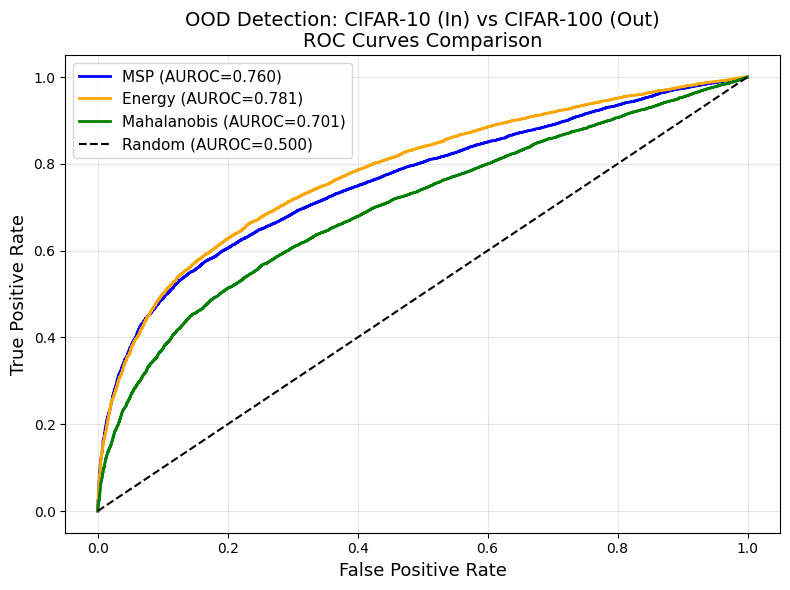

Plot saved!


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.special import softmax, logsumexp
import matplotlib.pyplot as plt

# ── Extract features and logits ──
def get_logits_and_features(loader):
    model.eval()
    all_logits = []
    all_features = []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            features = []
            def hook(module, input, output):
                features.append(input[0].cpu().numpy())
            handle = model.fc.register_forward_hook(hook)
            logits = model(inputs)
            handle.remove()
            all_logits.append(logits.cpu().numpy())
            all_features.append(features[0])
    return np.concatenate(all_logits), np.concatenate(all_features)

print("Extracting features...")
train_logits, train_features = get_logits_and_features(trainloader)
in_logits,    in_features    = get_logits_and_features(testloader_in)
out_logits,   out_features   = get_logits_and_features(testloader_out)
print(f"Train features: {train_features.shape}")
print(f"In-dist features: {in_features.shape}")
print(f"OOD features: {out_features.shape}")

# ── Method 1: MSP ──
def msp_score(logits):
    probs = softmax(logits, axis=1)
    return probs.max(axis=1)

msp_in  = msp_score(in_logits)
msp_out = msp_score(out_logits)
print("MSP scores computed!")

# ── Method 2: Energy Score ──
def energy_score(logits, T=1.0):
    return T * logsumexp(logits / T, axis=1)

energy_in  = energy_score(in_logits)
energy_out = energy_score(out_logits)
print("Energy scores computed!")

# ── Method 3: Mahalanobis with ridge regularization ──
def mahalanobis_score(train_features, train_logits, test_features, ridge=1e-3):
    train_labels = train_logits.argmax(axis=1)
    num_classes = 10
    class_means = []

    for c in range(num_classes):
        class_mask = train_labels == c
        class_means.append(train_features[class_mask].mean(axis=0))
    class_means = np.array(class_means)

    # Compute shared covariance with ridge regularization
    centered = train_features - class_means[train_labels]
    cov = np.cov(centered.T)
    cov += ridge * np.eye(cov.shape[0])  # ridge fixes near-singular matrix
    precision = np.linalg.inv(cov)

    scores = []
    for feat in test_features:
        dists = []
        for mean in class_means:
            diff = feat - mean
            dist = diff @ precision @ diff
            dists.append(dist)
        scores.append(-min(dists))
    return np.array(scores)

print("Computing Mahalanobis scores (3-4 minutes)...")
maha_in  = mahalanobis_score(train_features, train_logits, in_features)
maha_out = mahalanobis_score(train_features, train_logits, out_features)
print("Mahalanobis scores computed!")

# ── AUROC ──
def compute_auroc(in_scores, out_scores):
    labels = np.concatenate([np.ones(len(in_scores)),
                              np.zeros(len(out_scores))])
    scores = np.concatenate([in_scores, out_scores])
    return roc_auc_score(labels, scores)

auroc_msp    = compute_auroc(msp_in, msp_out)
auroc_energy = compute_auroc(energy_in, energy_out)
auroc_maha   = compute_auroc(maha_in, maha_out)

print(f"\n{'Method':<20} {'AUROC':>8}")
print("-" * 30)
print(f"{'MSP (Baseline)':<20} {auroc_msp:.4f}")
print(f"{'Energy Score':<20} {auroc_energy:.4f}")
print(f"{'Mahalanobis':<20} {auroc_maha:.4f}")

# ── Plot ──
fig, ax = plt.subplots(figsize=(8, 6))

for scores_in, scores_out, label, color in [
    (msp_in,    msp_out,    f"MSP (AUROC={auroc_msp:.3f})",         "blue"),
    (energy_in, energy_out, f"Energy (AUROC={auroc_energy:.3f})",   "orange"),
    (maha_in,   maha_out,   f"Mahalanobis (AUROC={auroc_maha:.3f})","green"),
]:
    lbls = np.concatenate([np.ones(len(scores_in)), np.zeros(len(scores_out))])
    scrs = np.concatenate([scores_in, scores_out])
    fpr, tpr, _ = roc_curve(lbls, scrs)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUROC=0.500)')
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("OOD Detection: CIFAR-10 (In) vs CIFAR-100 (Out)\nROC Curves Comparison", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ood_roc_curves.png", dpi=150)
plt.show()
print("Plot saved!")


Using device: cuda
Datasets ready!
Epoch [10/50] | Loss: 0.863 | Acc: 69.91%
Epoch [20/50] | Loss: 0.686 | Acc: 76.48%
Epoch [30/50] | Loss: 0.526 | Acc: 81.97%
Epoch [40/50] | Loss: 0.331 | Acc: 88.47%
Epoch [50/50] | Loss: 0.179 | Acc: 93.92%
Model saved!

Extracting features...
Features extracted! Shape: (50000, 512)
MSP computed!
Energy computed!
Computing Mahalanobis scores (~3 mins)...
Mahalanobis computed!

Method                  AUROC
------------------------------
MSP (Baseline)       0.8071
Energy Score         0.8338
Mahalanobis          0.6501


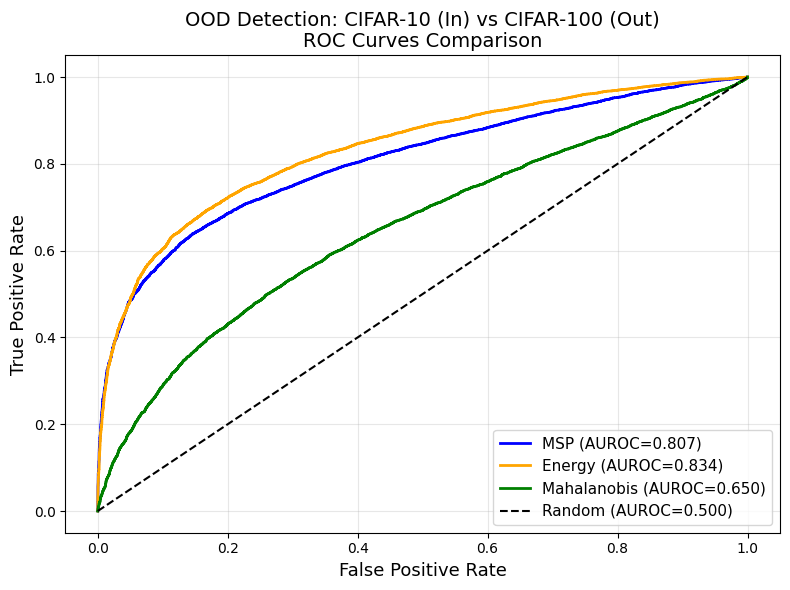

Plot saved as ood_roc_curves.png!


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.special import softmax, logsumexp
import matplotlib.pyplot as plt

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Data augmentation + normalization ──
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),  # augmentation prevents memorization
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset    = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset_in  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testset_out = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

trainloader    = torch.utils.data.DataLoader(trainset,    batch_size=128, shuffle=True,  num_workers=2)
testloader_in  = torch.utils.data.DataLoader(testset_in,  batch_size=128, shuffle=False, num_workers=2)
testloader_out = torch.utils.data.DataLoader(testset_out, batch_size=128, shuffle=False, num_workers=2)
print("Datasets ready!")

# ── ResNet-18 with Dropout before final layer ──
model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),        # dropout prevents overfitting
    nn.Linear(512, 10)
)
model = model.to(device)

# ── Training setup ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

# ── Training loop ──
def train(epochs=50):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        scheduler.step()
        if (epoch+1) % 10 == 0:
            print(f"Epoch [{epoch+1}/50] | Loss: {running_loss/len(trainloader):.3f} | "
                  f"Acc: {100.*correct/total:.2f}%")

train(epochs=50)
torch.save(model.state_dict(), 'resnet18_cifar10_v3.pth')
print("Model saved!")

# ── Feature extraction ──
# NOTE: because fc is now Sequential, hook needs to go on the Linear inside it
def get_logits_and_features(loader):
    model.eval()
    all_logits, all_features = [], []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            features = []
            def hook(module, input, output):
                features.append(input[0].cpu().numpy())
            handle = model.fc[1].register_forward_hook(hook)  # hook on Linear layer
            logits = model(inputs)
            handle.remove()
            all_logits.append(logits.cpu().numpy())
            all_features.append(features[0])
    return np.concatenate(all_logits), np.concatenate(all_features)

print("\nExtracting features...")
train_logits, train_features = get_logits_and_features(trainloader)
in_logits,    in_features    = get_logits_and_features(testloader_in)
out_logits,   out_features   = get_logits_and_features(testloader_out)
print(f"Features extracted! Shape: {train_features.shape}")

# ── OOD Scoring ──
msp_in  = softmax(in_logits,  axis=1).max(axis=1)
msp_out = softmax(out_logits, axis=1).max(axis=1)
print("MSP computed!")

energy_in  = logsumexp(in_logits,  axis=1)
energy_out = logsumexp(out_logits, axis=1)
print("Energy computed!")

def mahalanobis_score(train_features, train_logits, test_features, ridge=1e-2):
    train_labels  = train_logits.argmax(axis=1)
    class_means   = np.array([train_features[train_labels==c].mean(axis=0)
                               for c in range(10)])
    centered      = train_features - class_means[train_labels]
    cov           = np.cov(centered.T) + ridge * np.eye(512)
    precision     = np.linalg.inv(cov)
    scores = []
    for feat in test_features:
        dists = [((feat - m) @ precision @ (feat - m)) for m in class_means]
        scores.append(-min(dists))
    return np.array(scores)

print("Computing Mahalanobis scores (~3 mins)...")
maha_in  = mahalanobis_score(train_features, train_logits, in_features)
maha_out = mahalanobis_score(train_features, train_logits, out_features)
print("Mahalanobis computed!")

# ── AUROC ──
def compute_auroc(s_in, s_out):
    labels = np.concatenate([np.ones(len(s_in)), np.zeros(len(s_out))])
    scores = np.concatenate([s_in, s_out])
    return roc_auc_score(labels, scores)

auroc_msp    = compute_auroc(msp_in,    msp_out)
auroc_energy = compute_auroc(energy_in, energy_out)
auroc_maha   = compute_auroc(maha_in,   maha_out)

print(f"\n{'Method':<20} {'AUROC':>8}")
print("-" * 30)
print(f"{'MSP (Baseline)':<20} {auroc_msp:.4f}")
print(f"{'Energy Score':<20} {auroc_energy:.4f}")
print(f"{'Mahalanobis':<20} {auroc_maha:.4f}")

# ── Plot ROC curves ──
fig, ax = plt.subplots(figsize=(8, 6))
for s_in, s_out, label, color in [
    (msp_in,    msp_out,    f"MSP (AUROC={auroc_msp:.3f})",          "blue"),
    (energy_in, energy_out, f"Energy (AUROC={auroc_energy:.3f})",    "orange"),
    (maha_in,   maha_out,   f"Mahalanobis (AUROC={auroc_maha:.3f})", "green"),
]:
    lbls = np.concatenate([np.ones(len(s_in)), np.zeros(len(s_out))])
    scrs = np.concatenate([s_in, s_out])
    fpr, tpr, _ = roc_curve(lbls, scrs)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', label='Random (AUROC=0.500)')
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("OOD Detection: CIFAR-10 (In) vs CIFAR-100 (Out)\nROC Curves Comparison", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ood_roc_curves.png", dpi=150)
plt.show()
print("Plot saved as ood_roc_curves.png!")


Using device: cuda
Datasets ready!

Training ResNet-18 (50 epochs, ~20 mins)...
Epoch [10/50] | Loss: 0.878 | Acc: 69.57%
Epoch [20/50] | Loss: 0.679 | Acc: 76.62%
Epoch [30/50] | Loss: 0.530 | Acc: 81.89%
Epoch [40/50] | Loss: 0.328 | Acc: 88.72%
Epoch [50/50] | Loss: 0.181 | Acc: 93.89%
Model trained and saved!

Extracting features...
Done! Feature shape: (50000, 512)
MSP scores computed!
Energy scores computed!
Computing Mahalanobis+PCA scores...
Mahalanobis scores computed!

Method                       AUROC
-----------------------------------
MSP (Baseline)            0.8115
Energy Score              0.8397
Mahalanobis + PCA         0.6349


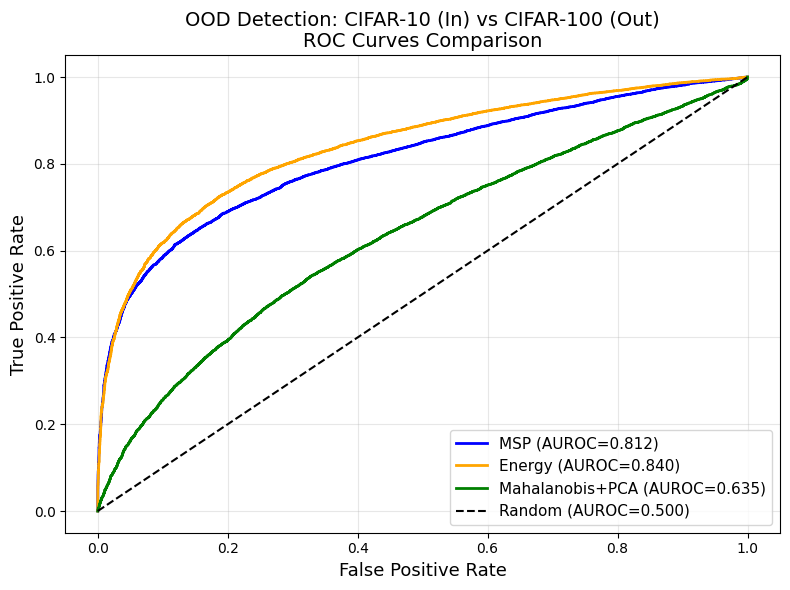

Plot saved as ood_roc_curves.png


In [2]:
# ════════════════════════════════════════════════════════
#  OOD Detection Project — Complete Code (Single Cell)
#  Methods: MSP, Energy Score, Mahalanobis+PCA
#  Dataset: CIFAR-10 (in-dist) vs CIFAR-100 (OOD)
# ════════════════════════════════════════════════════════

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from scipy.special import softmax, logsumexp
import matplotlib.pyplot as plt

# ── STEP 1: Device ──────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── STEP 2: Datasets ────────────────────────────────────
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset    = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform_train)
testset_in  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform_test)
testset_out = torchvision.datasets.CIFAR100(root='./data', train=False,
                                             download=True, transform=transform_test)

trainloader    = torch.utils.data.DataLoader(trainset,    batch_size=128,
                                              shuffle=True,  num_workers=2)
testloader_in  = torch.utils.data.DataLoader(testset_in,  batch_size=128,
                                              shuffle=False, num_workers=2)
testloader_out = torch.utils.data.DataLoader(testset_out, batch_size=128,
                                              shuffle=False, num_workers=2)
print("Datasets ready!")

# ── STEP 3: Model ───────────────────────────────────────
model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(512, 10)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1,
                      momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

print("\nTraining ResNet-18 (50 epochs, ~20 mins)...")
model.train()
for epoch in range(50):
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    scheduler.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/50] | Loss: {running_loss/len(trainloader):.3f} | "
              f"Acc: {100.*correct/total:.2f}%")

torch.save(model.state_dict(), 'resnet18_cifar10_final.pth')
print("Model trained and saved!")

# ── STEP 4: Feature Extraction ──────────────────────────
def get_logits_and_features(loader):
    model.eval()
    all_logits, all_features = [], []
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            features = []
            def hook(module, input, output):
                features.append(input[0].cpu().numpy())
            handle = model.fc[1].register_forward_hook(hook)
            logits = model(inputs)
            handle.remove()
            all_logits.append(logits.cpu().numpy())
            all_features.append(features[0])
    return np.concatenate(all_logits), np.concatenate(all_features)

print("\nExtracting features...")
train_logits, train_features = get_logits_and_features(trainloader)
in_logits,    in_features    = get_logits_and_features(testloader_in)
out_logits,   out_features   = get_logits_and_features(testloader_out)
print(f"Done! Feature shape: {train_features.shape}")

# ── STEP 5: OOD Scoring ─────────────────────────────────

# Method 1: MSP
msp_in  = softmax(in_logits,  axis=1).max(axis=1)
msp_out = softmax(out_logits, axis=1).max(axis=1)
print("MSP scores computed!")

# Method 2: Energy Score
energy_in  = logsumexp(in_logits,  axis=1)
energy_out = logsumexp(out_logits, axis=1)
print("Energy scores computed!")

# Method 3: Mahalanobis + PCA
def mahalanobis_score_pca(train_features, train_logits,
                           test_features, n_components=64, ridge=1e-2):
    pca = PCA(n_components=n_components)
    pca.fit(train_features)
    train_pca = pca.transform(train_features)
    test_pca  = pca.transform(test_features)

    train_labels = train_logits.argmax(axis=1)
    class_means  = np.array([train_pca[train_labels==c].mean(axis=0)
                              for c in range(10)])
    centered  = train_pca - class_means[train_labels]
    cov       = np.cov(centered.T) + ridge * np.eye(n_components)
    precision = np.linalg.inv(cov)

    scores = []
    for feat in test_pca:
        dists = [float((feat - m) @ precision @ (feat - m)) for m in class_means]
        scores.append(-min(dists))
    return np.array(scores)

print("Computing Mahalanobis+PCA scores...")
maha_in  = mahalanobis_score_pca(train_features, train_logits, in_features)
maha_out = mahalanobis_score_pca(train_features, train_logits, out_features)
print("Mahalanobis scores computed!")

# ── STEP 6: AUROC + Plot ────────────────────────────────
def compute_auroc(s_in, s_out):
    labels = np.concatenate([np.ones(len(s_in)), np.zeros(len(s_out))])
    scores = np.concatenate([s_in, s_out])
    return roc_auc_score(labels, scores)

auroc_msp    = compute_auroc(msp_in,    msp_out)
auroc_energy = compute_auroc(energy_in, energy_out)
auroc_maha   = compute_auroc(maha_in,   maha_out)

print(f"\n{'Method':<25} {'AUROC':>8}")
print("-" * 35)
print(f"{'MSP (Baseline)':<25} {auroc_msp:.4f}")
print(f"{'Energy Score':<25} {auroc_energy:.4f}")
print(f"{'Mahalanobis + PCA':<25} {auroc_maha:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
for s_in, s_out, label, color in [
    (msp_in,    msp_out,    f"MSP (AUROC={auroc_msp:.3f})",               "blue"),
    (energy_in, energy_out, f"Energy (AUROC={auroc_energy:.3f})",         "orange"),
    (maha_in,   maha_out,   f"Mahalanobis+PCA (AUROC={auroc_maha:.3f})",  "green"),
]:
    lbls = np.concatenate([np.ones(len(s_in)), np.zeros(len(s_out))])
    scrs = np.concatenate([s_in, s_out])
    fpr, tpr, _ = roc_curve(lbls, scrs)
    ax.plot(fpr, tpr, label=label, color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--', label='Random (AUROC=0.500)')
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("OOD Detection: CIFAR-10 (In) vs CIFAR-100 (Out)\nROC Curves Comparison", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ood_roc_curves.png", dpi=150)
plt.show()
print("Plot saved as ood_roc_curves.png")




In [ ]:
from google.colab import drive
drive.mount('/content/drive')